<a href="https://colab.research.google.com/github/leejsya/PyTorch/blob/main/DL_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [116]:
from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
import torch.optim as optim

import numpy as np
import pandas as pd
import joblib

In [102]:
b_cancer = load_breast_cancer()
display(b_cancer)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [103]:
df = pd.DataFrame(b_cancer.data, columns=b_cancer.feature_names)
df['target'] = b_cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [104]:
X = b_cancer.data.astype(np.float32)
y = b_cancer.target.astype(np.float32)

In [105]:
class BCancerDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    X_tensor = torch.tensor(self.X[index], dtype=torch.float32)
    y_tensor = torch.tensor(self.y[index], dtype=torch.float32)

    return X_tensor, y_tensor

In [106]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=5)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=5)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

train_dataset = BCancerDataset(X_train_scaled, y_train)
val_dataset = BCancerDataset(X_val_scaled, y_val)
test_dataset = BCancerDataset(X_test_scaled, y_test)

train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=32)

In [107]:
class BCancerModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(30, 32)
    self.fc2 = nn.Linear(32, 16)
    self.fc3 = nn.Linear(16, 8)
    self.fc4 = nn.Linear(8, 1)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout()

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.relu(self.fc3(x))
    x = self.dropout(x)
    x = self.fc4(x)
    return x

model = BCancerModel()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


BCancerModel(
  (fc1): Linear(in_features=30, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)

In [108]:
epochs = 10

for epoch in range(epochs):
  model.train()

  for train_batch in train_dataloader:
    x_train, y_train = train_batch[0].to(device), train_batch[1].to(device)

    pred = model(x_train).squeeze()
    loss = loss_fn(pred, y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [110]:
model.eval()
with torch.no_grad():
  losses = []
  predictions = []
  targets = []
  correct = 0
  for val_batch in val_dataloader:
    x_val, y_val = val_batch[0].to(device), val_batch[1].to(device)
    pred = model(x_val).squeeze()
    loss = loss_fn(pred, y_val)
    losses.append(loss.item())
    predictions.extend((pred > 0).cpu().numpy())
    targets.extend(y_val.numpy())


val_loss_avg = sum(losses) / len(losses)
print(f"validation loss: {val_loss_avg:.4f}")
print()
print(f"report:\n{classification_report(targets, predictions)}")

validation loss: 0.1421

report:
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96        27
         1.0       0.94      1.00      0.97        30

    accuracy                           0.96        57
   macro avg       0.97      0.96      0.96        57
weighted avg       0.97      0.96      0.96        57



In [111]:
model.eval()
with torch.no_grad():
  losses = []
  predictions = []
  targets = []
  correct = 0
  for test_batch in test_dataloader:
    x_val, y_val = val_batch[0].to(device), val_batch[1].to(device)
    pred = model(x_val).squeeze()
    loss = loss_fn(pred, y_val)
    losses.append(loss.item())
    predictions.extend((pred > 0).cpu().numpy())
    targets.extend(y_val.numpy())


val_loss_avg = sum(losses) / len(losses)
print(f"validation loss: {val_loss_avg:.4f}")
print()
print(f"report:\n{classification_report(targets, predictions)}")

validation loss: 0.1140

report:
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.95        20
         1.0       0.94      1.00      0.97        30

    accuracy                           0.96        50
   macro avg       0.97      0.95      0.96        50
weighted avg       0.96      0.96      0.96        50



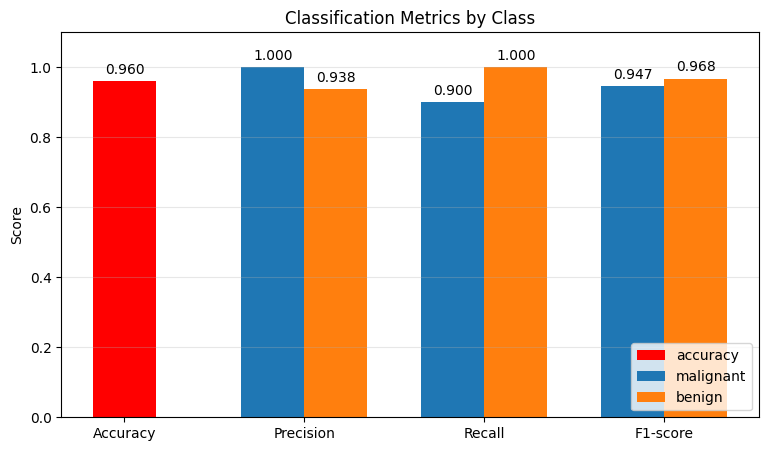

In [126]:
import matplotlib.pyplot as plt

report = classification_report(
    targets, predictions, target_names=b_cancer.target_names, output_dict=True)

classes = ['malignant', 'benign']
metrics = ['precision', 'recall', 'f1-score']
accuracy = report['accuracy']

x = np.arange(len(metrics)) + 1
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

acc_bar = ax.bar(0, accuracy, width, color='red', label='accuracy')
ax.bar_label(acc_bar, fmt='%.3f', padding=3)

for i, cls in enumerate(classes):
    values = [report[cls][m] for m in metrics]
    bars = ax.bar(x + (i - 0.5) * width, values, width, label=cls)
    ax.bar_label(bars, fmt='%.3f', padding=3)

ax.set_xticks(np.arange(len(metrics) + 1), ['Accuracy', 'Precision', 'Recall', 'F1-score'])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Classification Metrics by Class')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.show()

In [127]:
torch.save(model.state_dict(), 'model.pt')
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']